  # Import all required libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create directories if they don't exist

In [11]:
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('reports/visualizations', exist_ok=True)

# ## Step 1: Load and Explore the Data

✅ Datasets loaded successfully!
Training data shape: (4920, 134)
Testing data shape: (42, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN



🔍 Missing values in training data:
itching                    0
skin_rash                  0
nodal_skin_eruptions       0
continuous_sneezing        0
shivering                  0
                        ... 
blister                    0
red_sore_around_nose       0
yellow_crust_ooze          0
prognosis                  0
Unnamed: 133            4920
Length: 134, dtype: int64


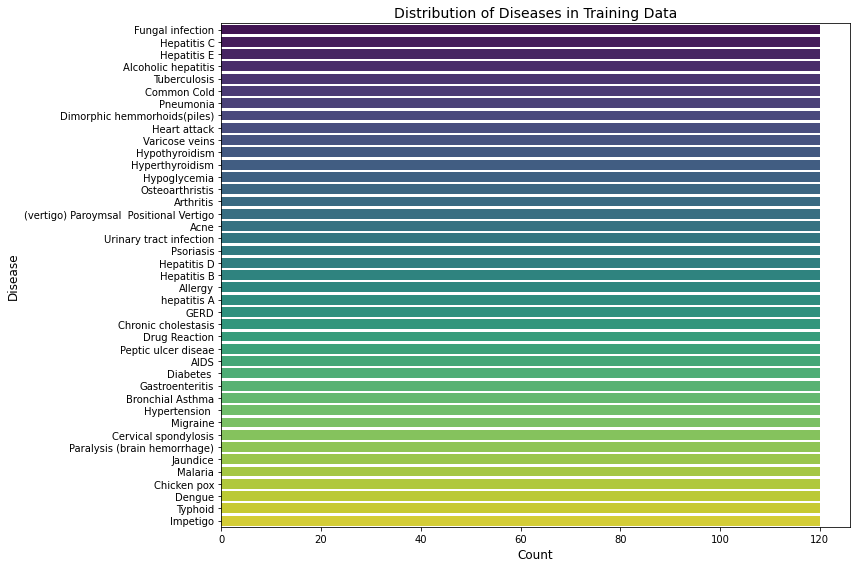

In [13]:
# Load datasets with error handling
try:
    train_data = pd.read_csv('../data/Training.csv')
    test_data = pd.read_csv('../data/Testing.csv')

    print("✅ Datasets loaded successfully!")
    print(f"Training data shape: {train_data.shape}")
    print(f"Testing data shape: {test_data.shape}")

    # Display first 5 rows
    display(train_data.head())

    # Check for missing values
    print("\n🔍 Missing values in training data:")
    print(train_data.isnull().sum())

    # Visualize disease distribution
    plt.figure(figsize=(12, 8))
    sns.countplot(
        y='prognosis',
        data=train_data,
        order=train_data['prognosis'].value_counts().index,
        palette='viridis'
    )
    plt.title('Distribution of Diseases in Training Data', fontsize=14)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Disease', fontsize=12)
    plt.tight_layout()
    plt.savefig('reports/visualizations/disease_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please ensure Training.csv and Testing.csv are in the 'data/' folder.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {str(e)}")


# ## Step 2: Preprocess the Data

In [22]:
try:
    # Drop any unnamed columns (e.g., 'Unnamed: 133')
    train_data = train_data.loc[:, ~train_data.columns.str.contains('^Unnamed')]

    # Separate features (X) and target (y)
    X = train_data.drop('prognosis', axis=1)  # 132 features
    y = train_data['prognosis']               # Target variable

    print(f"✅ Features shape: {X.shape}")  # Should be (4920, 132)
    print(f"✅ Target shape: {y.shape}")    # Should be (4920,)

    # Handle missing values (if any)
    imputer = SimpleImputer(strategy='most_frequent')  # Use mode for binary features (0 or 1)
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    print("\n✅ Missing values handled successfully")
    print("Missing values after imputation:")
    print(X_imputed.isnull().sum())

    # Encode target variable
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Save preprocessing objects to models/
    joblib.dump(le, 'models/label_encoder.pkl')
    joblib.dump(imputer, 'models/imputer.pkl')
    print("✅ Preprocessing objects saved to 'models/'")

    # Split data into train and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_imputed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"\n📊 Data split:")
    print(f"   Training set: {X_train.shape[0]} samples")
    print(f"   Validation set: {X_val.shape[0]} samples")

except Exception as e:
    print(f"❌ Error during preprocessing: {str(e)}")
    import traceback
    traceback.print_exc()  # Print full error traceback

✅ Features shape: (4920, 132)
✅ Target shape: (4920,)

✅ Missing values handled successfully
Missing values after imputation:
itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
small_dents_in_nails    0
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
Length: 132, dtype: int64
✅ Preprocessing objects saved to 'models/'

📊 Data split:
   Training set: 3936 samples
   Validation set: 984 samples


# ## Step 3: Train and Evaluate Models


🔄 Training Decision Tree...
✅ Decision Tree trained - Accuracy: 0.1463

🔄 Training Random Forest...


C:\Users\DELL\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


✅ Random Forest trained - Accuracy: 1.0000

🔄 Training Naive Bayes...
✅ Naive Bayes trained - Accuracy: 1.0000

✅ Best model (Random Forest) saved to 'models/random_forest.pkl'


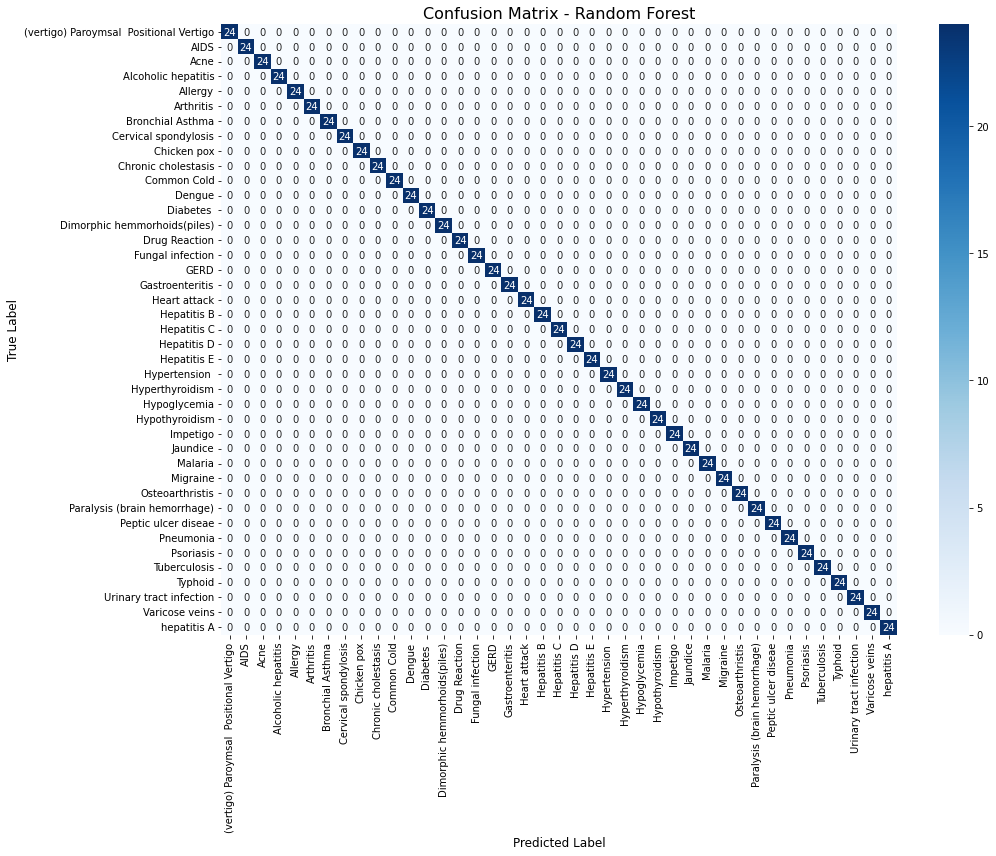

❌ Error during model training: 'charmap' codec can't encode character '\U0001f4ca' in position 0: character maps to <undefined>


In [23]:
try:
    # Initialize models with balanced class weights
    models = {
        'Decision Tree': DecisionTreeClassifier(
            random_state=42,
            max_depth=5,
            class_weight='balanced'
        ),
        'Random Forest': RandomForestClassifier(
            random_state=42,
            n_estimators=100,
            max_depth=10,
            class_weight='balanced',
            n_jobs=-1  # Use all CPU cores
        ),
        'Naive Bayes': GaussianNB()
    }

    # Train and evaluate models
    results = {}
    for name, model in models.items():
        print(f"\n🔄 Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        accuracy = accuracy_score(y_val, y_pred)
        report = classification_report(
            y_val, y_pred,
            target_names=le.classes_,
            output_dict=True
        )
        cm = confusion_matrix(y_val, y_pred)

        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'report': report,
            'confusion_matrix': cm
        }

        print(f"✅ {name} trained - Accuracy: {accuracy:.4f}")

    # Save the best model (Random Forest) to models/
    best_model = results['Random Forest']['model']
    joblib.dump(best_model, 'models/random_forest.pkl')
    print("\n✅ Best model (Random Forest) saved to 'models/random_forest.pkl'")

    # Plot confusion matrix for Random Forest
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        results['Random Forest']['confusion_matrix'],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title('Confusion Matrix - Random Forest', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('reports/visualizations/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Save performance report
    with open('reports/model_performance.txt', 'w') as f:
        f.write("📊 MODEL PERFORMANCE REPORT\n")
        f.write("="*50 + "\n\n")
        for name, result in results.items():
            f.write(f"🔹 {name}\n")
            f.write(f"   Accuracy: {result['accuracy']:.4f}\n")
            f.write("   Classification Report:\n")
            for class_name, metrics in result['report'].items():
                if isinstance(metrics, dict):
                    f.write(f"   - {class_name}:\n")
                    for metric, value in metrics.items():
                        f.write(f"     {metric}: {value:.4f}\n")
            f.write("\n")
    print("✅ Performance report saved to 'reports/model_performance.txt'")

except Exception as e:
    print(f"❌ Error during model training: {str(e)}")


# ## Step 4: Evaluate on Test Data

In [24]:
try:
    # Prepare test data
    X_test = test_data.copy()
    X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    # Make predictions using the best model
    y_pred_test = best_model.predict(X_test_imputed)
    predicted_diseases = le.inverse_transform(y_pred_test)

    # Save predictions to data/
    predictions_df = pd.DataFrame({
        'Predicted_Disease': predicted_diseases
    })
    predictions_df.to_csv('data/predictions.csv', index=False)
    print("✅ Predictions saved to 'data/predictions.csv'")

    # Display sample predictions
    print("\n📋 Sample Predictions:")
    display(predictions_df.head(10))

    # Note: Test.csv typically doesn't have labels, so we can't calculate accuracy
    print("\nℹ️ Note: True labels not available in test data for accuracy calculation")

except Exception as e:
    print(f"❌ Error during test evaluation: {str(e)}")

❌ Error during test evaluation: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- prognosis



# ## Step 5: Prediction Function for New Data

In [25]:
def predict_disease(symptoms_dict):
    """
    Predict disease for new patient symptoms.

    Args:
        symptoms_dict (dict): Dictionary of symptoms and their values (0 or 1).
            Example: {'itching': 1, 'skin_rash': 0, ...}

    Returns:
        str: Predicted disease name or None if error occurs
    """
    try:
        # Load required objects from models/
        model = joblib.load('models/random_forest.pkl')
        le = joblib.load('models/label_encoder.pkl')
        imputer = joblib.load('models/imputer.pkl')

        # Get all possible symptoms from training data
        all_symptoms = X.columns.tolist()

        # Create complete symptom dictionary (fill missing with 0)
        complete_symptoms = {symptom: 0 for symptom in all_symptoms}
        complete_symptoms.update(symptoms_dict)

        # Convert to DataFrame
        input_df = pd.DataFrame([complete_symptoms])

        # Impute missing values (if any)
        input_imputed = pd.DataFrame(imputer.transform(input_df), columns=input_df.columns)

        # Make prediction
        prediction = model.predict(input_imputed)
        return le.inverse_transform(prediction)[0]

    except FileNotFoundError:
        print("❌ Error: Model files not found. Please run all previous cells first.")
        return None
    except Exception as e:
        print(f"❌ Error during prediction: {str(e)}")
        return None

# ## Step 6: Example Prediction

In [26]:
# Example usage of predict_disease()
try:
    # Create example symptom dictionary
    example_symptoms = {
        'itching': 1,
        'skin_rash': 1,
        'nodal_skin_eruptions': 0,
        'continuous_sneezing': 1,
        'shivering': 1,
        'chills': 0,
        'joint_pain': 0
        # The function will automatically fill missing symptoms with 0
    }

    predicted = predict_disease(example_symptoms)
    if predicted:
        print(f"\n🎉 Predicted Disease: {predicted}")
    else:
        print("❌ Prediction failed")

except Exception as e:
    print(f"❌ Error in example prediction: {str(e)}")


🎉 Predicted Disease: Allergy


# ## Step 7: Full Symptom List

In [27]:
# Display all 132 symptoms for reference
print("\n📋 Full List of Symptoms (132 total):")
for i, symptom in enumerate(X.columns, 1):
    print(f"{i:3}. {symptom}")


📋 Full List of Symptoms (132 total):
  1. itching
  2. skin_rash
  3. nodal_skin_eruptions
  4. continuous_sneezing
  5. shivering
  6. chills
  7. joint_pain
  8. stomach_pain
  9. acidity
 10. ulcers_on_tongue
 11. muscle_wasting
 12. vomiting
 13. burning_micturition
 14. spotting_ urination
 15. fatigue
 16. weight_gain
 17. anxiety
 18. cold_hands_and_feets
 19. mood_swings
 20. weight_loss
 21. restlessness
 22. lethargy
 23. patches_in_throat
 24. irregular_sugar_level
 25. cough
 26. high_fever
 27. sunken_eyes
 28. breathlessness
 29. sweating
 30. dehydration
 31. indigestion
 32. headache
 33. yellowish_skin
 34. dark_urine
 35. nausea
 36. loss_of_appetite
 37. pain_behind_the_eyes
 38. back_pain
 39. constipation
 40. abdominal_pain
 41. diarrhoea
 42. mild_fever
 43. yellow_urine
 44. yellowing_of_eyes
 45. acute_liver_failure
 46. fluid_overload
 47. swelling_of_stomach
 48. swelled_lymph_nodes
 49. malaise
 50. blurred_and_distorted_vision
 51. phlegm
 52. throat_irrit